<a href="https://colab.research.google.com/github/dhyun16/ESAA/blob/main/0911HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 03 시본(Seaborn)

#### 정보의 종류에 따른 시각화 차트 유형
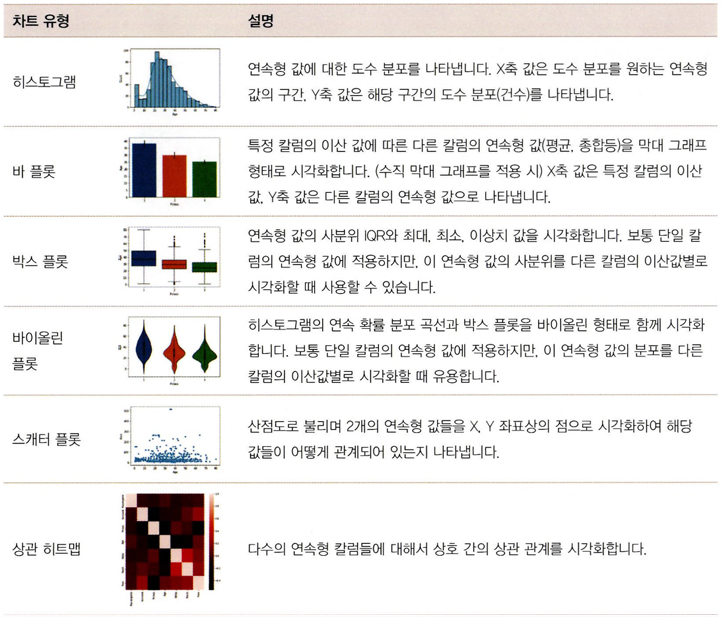

+ **바 플롯**(막대 그래프)은 특정 칼럼의 이산 값을 기준으로 다른 칼럼의 연속형 값을 막대 그래프로 시각화
+ 다른 모든 플롯들은 기본적으로 *연속형 칼럼 값*에 대한 시각화
+ **히스토그램**과 **바이올린 플롯**은 연속형 데이터의 분포가 정규 분포인지 왜곡되어 있는지 시각화
+ **스캐터 플롯**(산점도)는 2개의 연속형 칼럼들에 대한 분포 및 관계를 점으로 시각화
+ **상관 히트맵**은 다수의 연속형 칼럼들의 상관관계를 온도를 나타내는 시각적인 컬러 기반으로 표현

시본
+ X축과 Y축으로 구성된 이차워 축에서 데이터를 시각화해주므로 2개의 변수(칼럼)에 대한 정보
를 기본적으로 표출
+ 시본의 대부분 시각화 함수들은 *hue*라는 인자를 통해서 또는 플롯의 유형에 따라 연속형 데이터의 정보를 다른 이산형 데이터 값으로 세분화된 정보로 표현할 수 있게 만들어줘서 2개의 변수가 아닌 3개의 변수도 함께 정보로 시각화할 수 있음

#### 히스토그램(Histogram)

히스토그램
+ 막대 차트처럼 보이지만 연속형 값을 범위 또는 구간으로 그룹화해 개별 구간에 해당되는 데이터의 건수를 시각화
+ ```histplot()```은 Axes 레벨 함수
+ ```displot()```은 Figure 레벨 함수



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
titanic_df = pd.read_csv('/content/drive/MyDrive/ESAA/titanic_train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


```histplot()``` 함수
+ 인자로 히스토그램 대상이 되는 Age 칼럼 데이터를 가지는 ```titanic_df['Age']```를 입력하고, 구간의 개수는 bins=20으로 설정

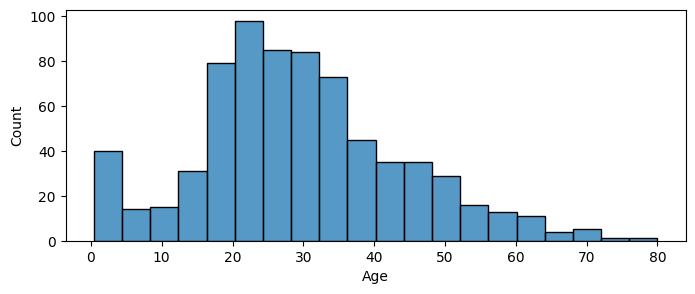

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시본에서도 plt.figure()의 figsize 인자를 입력하여 전체 Figure의 크기 조절
plt.figure(figsize=(8, 3))

# DataFrame의 칼럼명을 자동으로 인식해서 xlabel 값을 할당. ylabel 값은 Count로 설정.
sns.histplot(titanic_df['Age'], bins=20)
plt.show()

대부분의 시각화 함수들은 data, x, y를 각각 인자로 가지는데, data 인자는 시각화 대상 *DataFrame
객체*, x 인자는 *X축에 사용될 칼럼명*, y인자는 *Y축에 사용될 칼럼명*을 입력받음

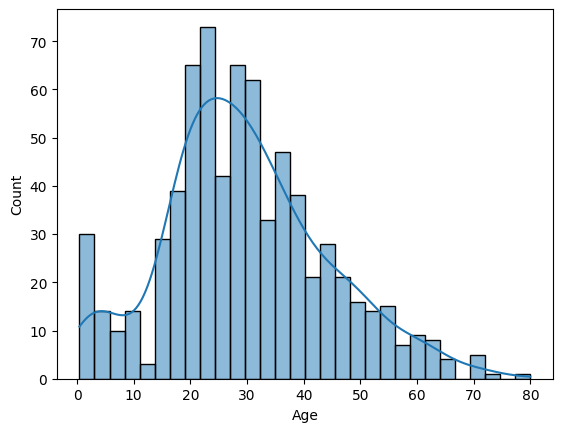

In [4]:
sns.histplot(x='Age', data=titanic_df, bins=30, kde=True) # kde=True 연속 확률분포 곡선
plt.show()

```displot()```  
+ Figure 레벨 함수의 특징은 맷플롯립 API 사용을 최소화하고, 기본 맷플롯립에서 사용하는 기능들을 Figure 레벨 함수의 인자 등으로 대체하게 설계

<Figure size 800x400 with 0 Axes>

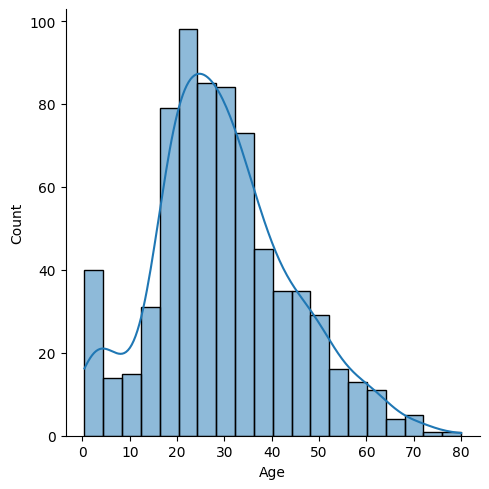

In [5]:
import seaborn as sns

# seaborn의 figure레벨 그래프는 plt.figure( )로 Figure 크기를 조절할 수 없습니다.
plt.figure(figsize=(8, 4))
sns.displot(x='Age', data=titanic_df, kde=True)
plt.show()

+ Figure의 크기를 조절하기 위한 인자로 height와 aspect가 주어지는데, ```height```는 세로(높이)의 크기를 의미하며 ```aspect```는 가로와 세로의 배율을 의미
+  width와 같은 별도의 가로(너비) 크기를 설정하는 인자는 제공되지 않음

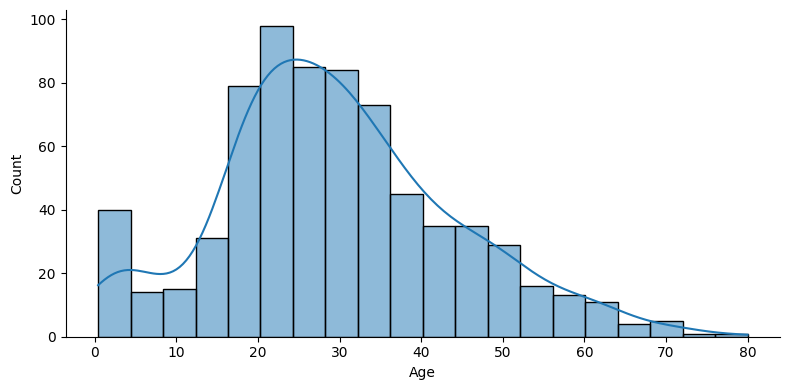

In [6]:
import seaborn as sns

sns.displot(titanic_df['Age'], kde=True, height=4, aspect=2)
plt.show()

#### 카운트 플롯

카운트플롯
+ *이산형 값*의 건수를 막대 그래프 형태로 시각화


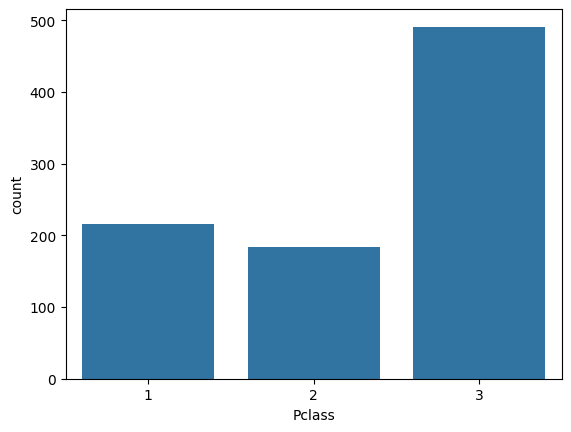

In [7]:
sns.countplot(x='Pclass', data=titanic_df)
plt.show()

#### 바 플롯(barplot)

바 플롯
+ 2차원 축 기반의 시각화
+ 보통 X축 값이 이산형 값, Y축에 해당하는 칼럼값의 평균이나 총합으로 표현되는 연속형 값
+ 기본적으로 *Y축 값의 평균 값*을 나타냄
+ 평균 외에도 총합, 중앙값 등을 나타낼 수도 있는데,
이는 estimator 인자값을 설정하여 변경할 수 있음


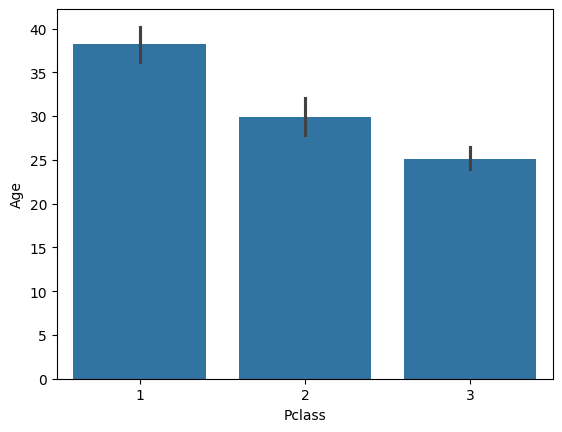

In [8]:
# 자동으로 xlabel, ylabel을 barplot( )의 x 인자값인 Pclass, y 인자값이 Age로 설정.
sns.barplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

+ 시본에서는 맷플롯립과 다르게 pyplot 모듈의 xlabel(),
ylabel() 함수를 사용하지 않고도 X축명 Pclass와 Y축명 Age를 자동으로 설정

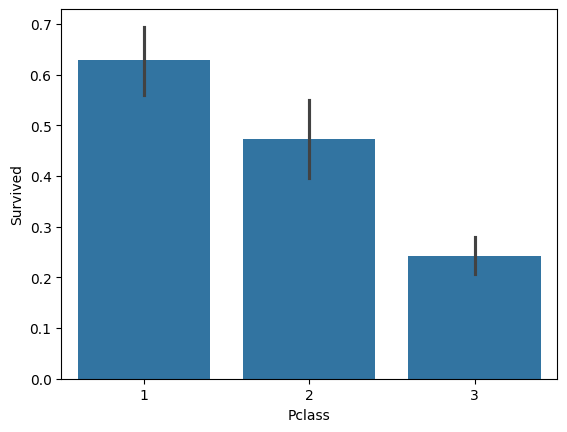

In [9]:
sns.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.show()

+ 수직 또는 수평 막대 그래프를 시각화 선택을 ```orient``` 인자로 설정
  * orient가 v일 경우는 수직 (Vertical) 막대 그래프를, h일 경우는 수평 (Horizontal) 막대 그래프를 그림
+ 수직 막대 그래프의 경우 일반적으로 X축 값을 **이산형 값**으로 설정하며 이산형 값은 숫자값
또는 문자열값 모두 가능  
+ 수직 막대 그래프의 Y축 값을 문자열 값으로 설정하면 안됨  
+  만약 Y축 값을 문자열 값으로 입력하고 X축 값을 숫자형
값으로 입력하면 barplot() 함수는 자동으로 수직 막대 그래프가 아닌 수평 막대 그래프로 시각화

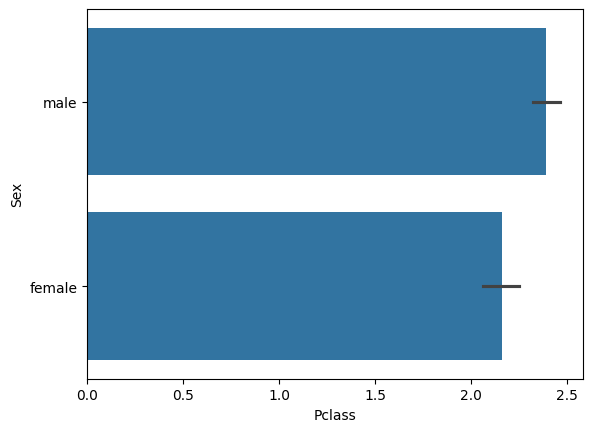

In [10]:
### 우축을 문자값으로 설정하면 자동으로 수평 막대 그래프 변환
sns.barplot(x='Pclass', y='Sex', data=titanic_df)
plt.show()

+ **바 플롯은 수직 막대 그래프의 경우 Y축 값을 연속형 값으로, 수평 막대 그래프는 X축 값을 연속형 값으로 설정해 줘야 시각적으로 정보가 의미하는 바를 명확하게 파악할 수 있음**

<Axes: xlabel='Name', ylabel='Sex'>

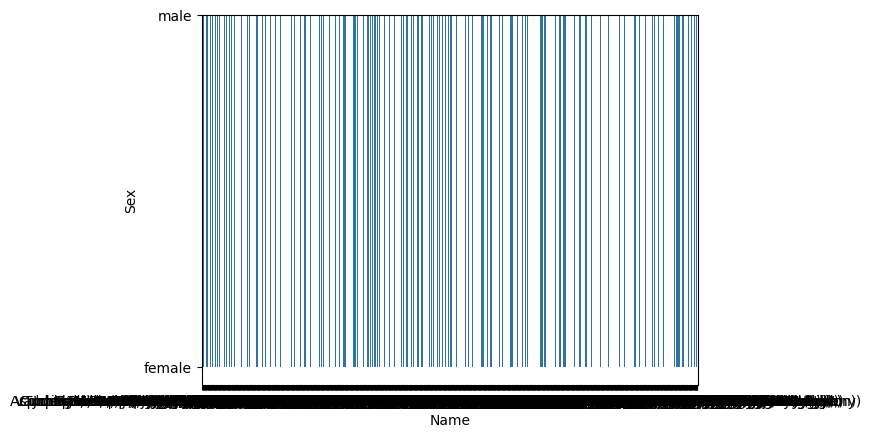

In [11]:
# x 인자로 문자열인 Name을, y 인자로 문자열인 Sex를 입력하므로 barplot은 오류를 발생.
sns.barplot(x='Name', y='Sex', data=titanic_df)

+ ```estimator=sum```으로 설정하면 Y축 표현값을 평균이 아니라 총합으로 표현

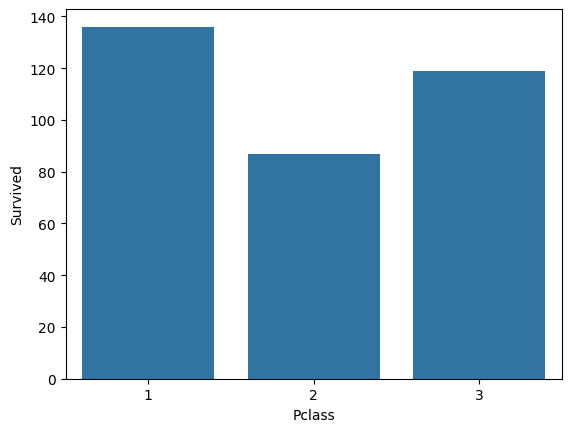

In [12]:
# estimator=sum을 적용하여 평균이 아니라 총합으로 표현.
sns.barplot(x='Pclass', y='Survived', data=titanic_df, errorbar=None, estimator=sum) # Seaborn은 각 범주(Pclass)별 데이터의 불확실성을 나타내기 위해 기본적으로 95% 신뢰구간을 계산하여 막대 끝에 검은 선(오차 막대)으로 표시
plt.show()

#### barplot() 함수의 hue 인자를 사용하여 시각화 정보를 추가적으로 세분화하기

barplot() 함수는 hue 인자를 통해서 이러한 세부 정보를 추가적으로 전달

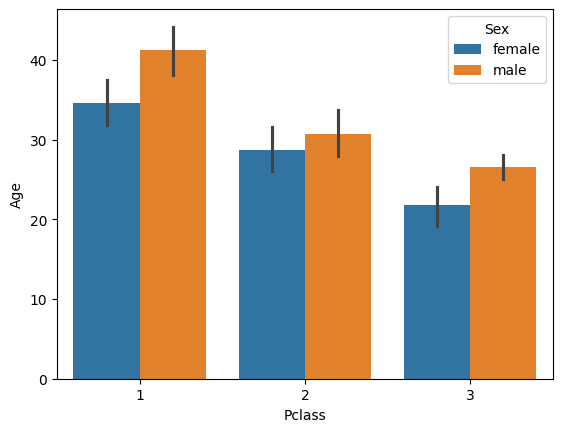

In [13]:
# 아래는 Pclass가 X축값이며 hue파라미터로 Sex를 설정
# 개별 Pclass 값별로 Sex에 따른 Age 평균 값을 구함.
sns.barplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

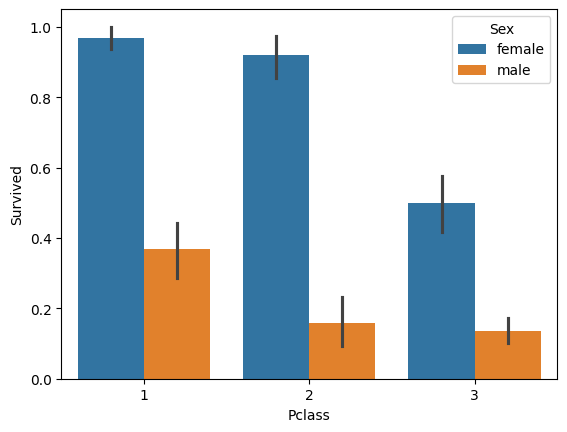

In [14]:
# 개별 Pclass 값별로 Sex에 따른 Survived 평균값을 구함.
# Pclass가 X축 값이며 Survived가、(축 값. hue 파라미터로 Sex를 설정
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)
plt.show()

#### 박스 플롯

```boxplot()```  
+  x 또는y 인자로 연속형 값을 입력할 수 있는데, y에 입력 시 수직 박스 플롯을, x에 입력 시 수평 박스 플롯을 나타냄


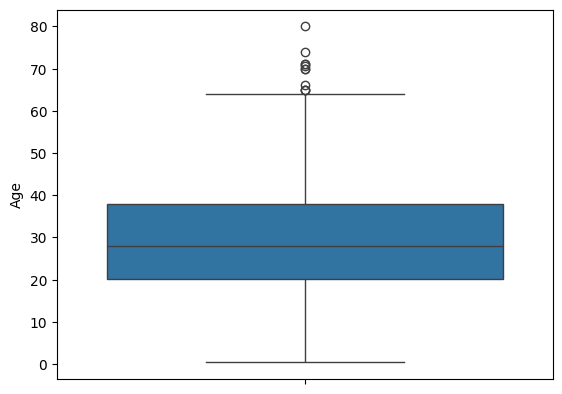

In [15]:
sns.boxplot(y='Age', data=titanic_df)
plt.show()

+  추가적인 세분화 레벨에서도 적용이 가능
   * 여러 개의 Pclass 값별로 Age에 대한 여러 개의 박스 플롯을 시각화하기를 원한다면 y 인자에 Age를, 그리고 x 인자에 Pclass를 입력
   * 반드시 x 인자는 이산형 값. 연속형 값을 입력하면 너무 많은 박스플롯들을 그림

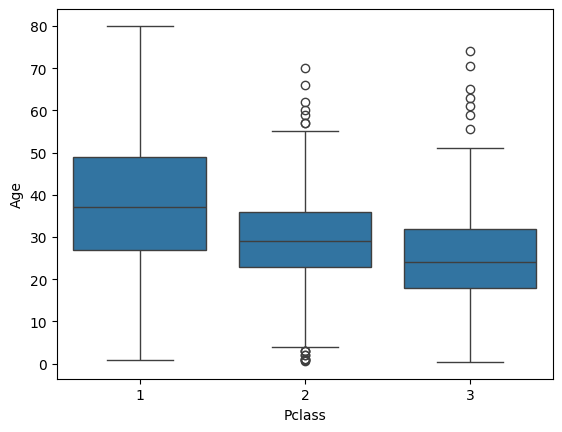

In [16]:
sns.boxplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

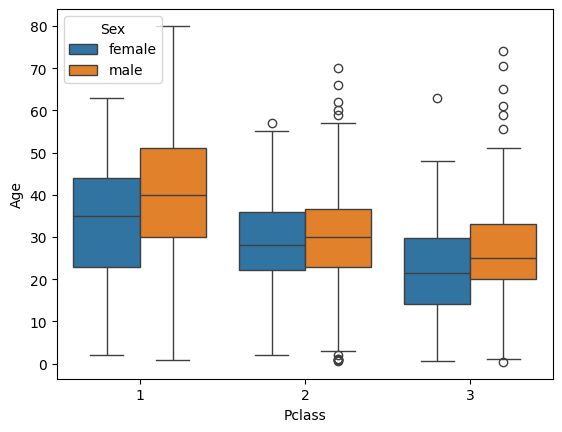

In [17]:
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

#### 바이올린 플롯

바이올린 플롯  
+  **히스토그램**의 연속 확률 분포 곡선과 **박스 플롯**을 함께 시각화할 수 있음  
+ 연속형 값에 적용해야 의미 있는 정보로 시각화될 수 있음  
+ ```violinplot()``` 함수
   +  x 또는 y 인자로 연속형 값을 입력할 수 있는데, y에 입력 시 수직 바이올린 플롯을, 호에 입력 시 수평 바이올린 플롯을 나타냄

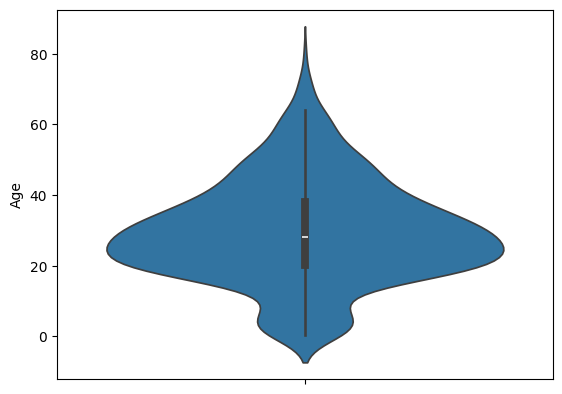

In [18]:
# Age 칼럼에 대한 수직 바이올린 플롯 시각화
sns.violinplot(y='Age', data=titanic_df)
plt.show()

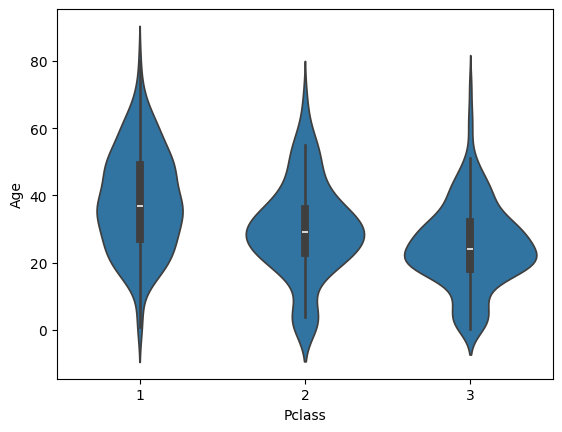

In [19]:
# x축값인 Pclass의 값별로 y축 값인 Age의 바이올린 플롯을 그림
# pClass값별 Age 데이터 분포를 비교하여 볼 수 있음.
sns.violinplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

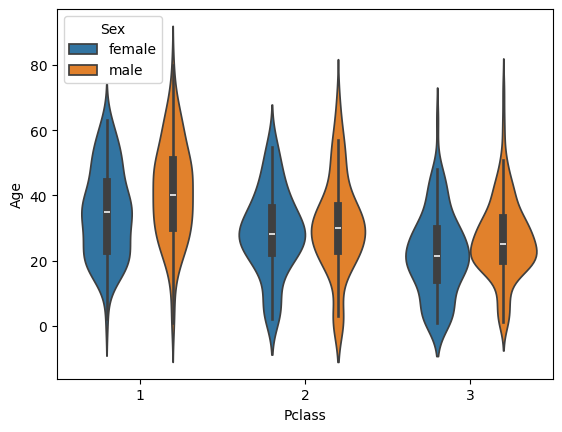

In [20]:
# x축값인 개별 Pclass 내에서 Sex값별로 y축 값인 Age의 바이올린 플롯을 그림
sns.violinplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

### subplots를 이용하여 시본의 다양한 그래프를 시각화

+ 시본의 다양한 그래프를 여러 개의 subplots 상에서 시각화
+ Axes레벨 시각화 함수는 ax라는 인자를 가지고 있음. 시각화 함수 호출 시 이 ax 인자에 개별 Axes 객체를 할당
   *

index： 0
index： 1
index： 2


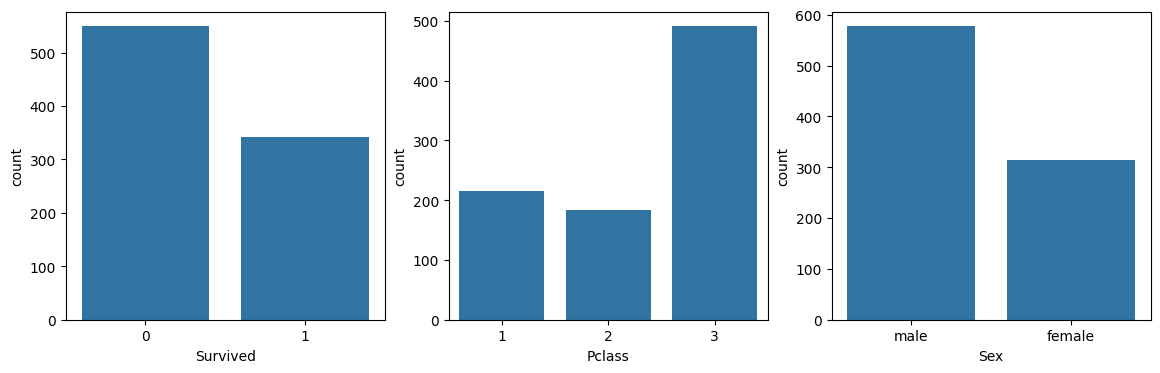

In [21]:
cat_columns = ['Survived', 'Pclass', 'Sex']

# nrows는 1 이고 ncols는 칼럼의 개수만큼인 subplots을 설정.
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
  print('index：',index)
  # seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정.
  sns.countplot(x=column, data=titanic_df, ax=axs[index])

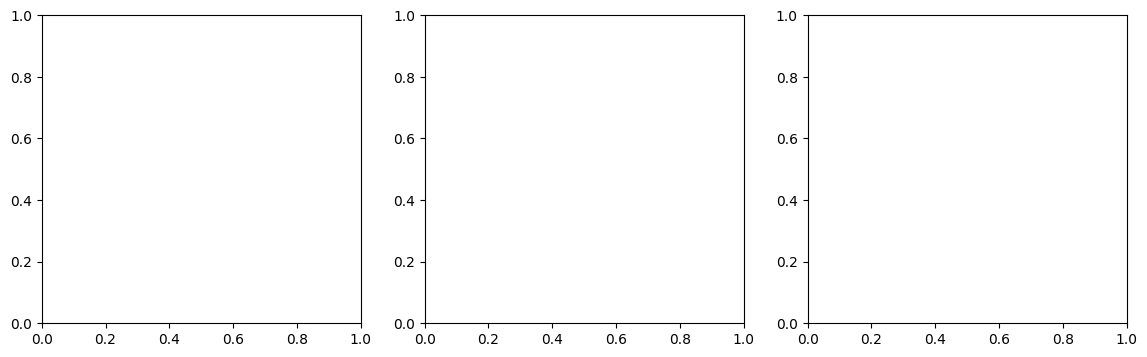

In [22]:
cat_columns = ['Survived', 'Pclass', 'Sex']

# nrows는 1 이고 ncols는 칼럼의 개수만큼인 subplots을 설정.
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))


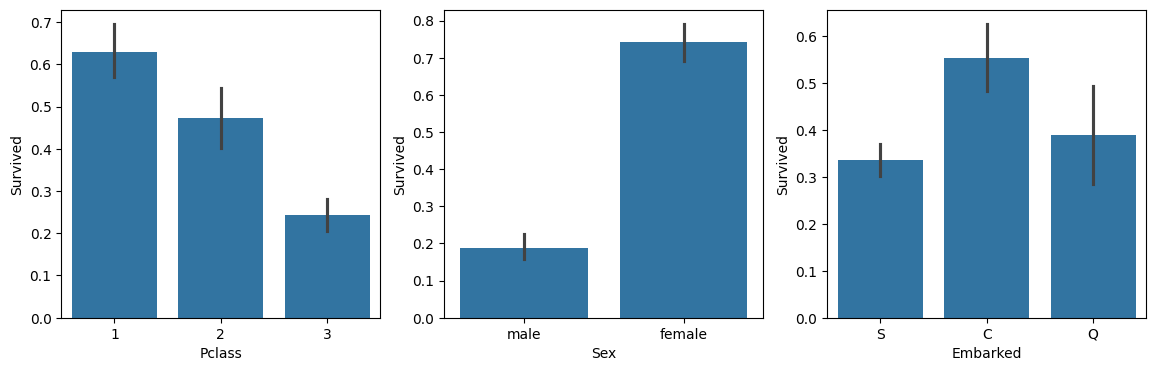

In [23]:
cat_columns = ['Pclass', 'Sex', 'Embarked']

# nrows는 1 이고 ncols는 칼럼의 개수만큼인 subplots을 설정.
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
  # seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정.
  sns.barplot(x=column, y='Survived', data=titanic_df, ax=axs[index])

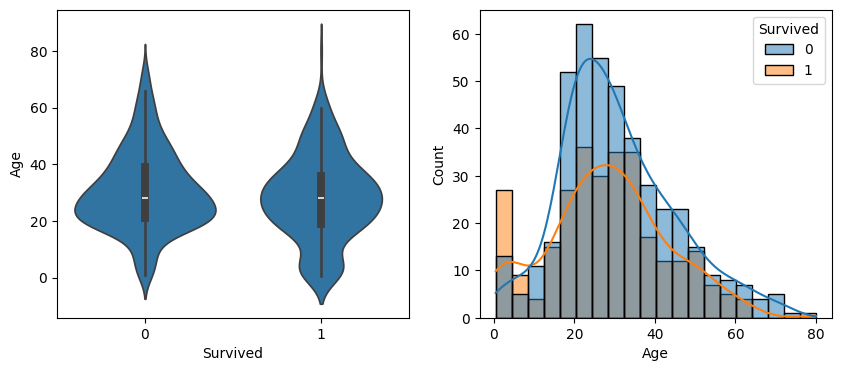

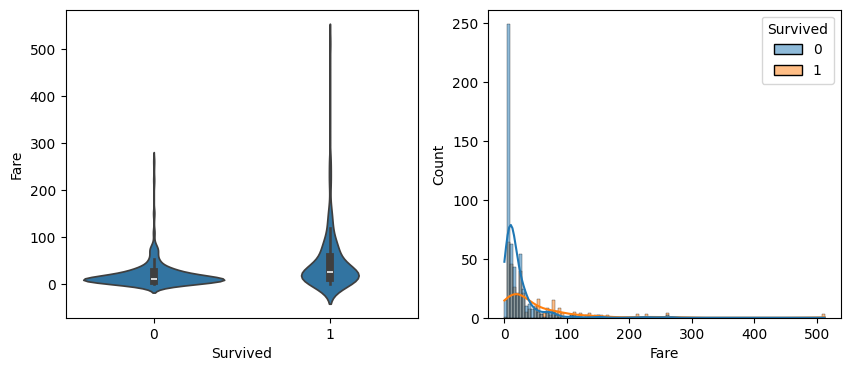

In [24]:
cont_columns = ['Age', 'Fare']

# 리스트로 할당된 칼럼들의 개수만큼 루프 수행.
for column in cont_columns:
  # 왼쪽에는 바이올린 플롯, 오른쪽에는 히스토그램을 시각화. nrows는 1, ncols=2인 서브플롯 생성.
  fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
  # 왼쪽 Axes 객체에는 Survived값 0, 1 별 개별 칼럼의 바이올린 플롯 시각화.
  sns.violinplot(x='Survived', y=column, data=titanic_df, ax=axs[0])
  # 오른쪽 Axes 객체에는 Survived 값에 따른 개별 칼럼의 히스토그램 시각화
  sns.histplot(x=column, data=titanic_df, kde=True, hue='Survived', ax=axs[1])

#### 산점도, 스캐터 플롯(Scatter Plot)

산점도
+ 좌표상에 점을 표시하여 변수 간의 관계를 나타냄
+ 2차원 축, X축과 Y축이 있다면 X축에 해당하는 변숫값과 Y축에 해당하는 변숫값이 만나는 지점에 점을 표시하여 변수 간의 관계를 시각화
+ X축 값, Y축 값 모두 연속형 숫자값을 적용해야 의미 있는 시각화정보를 얻을 수 있음
+ ```scatterplot``` 함수


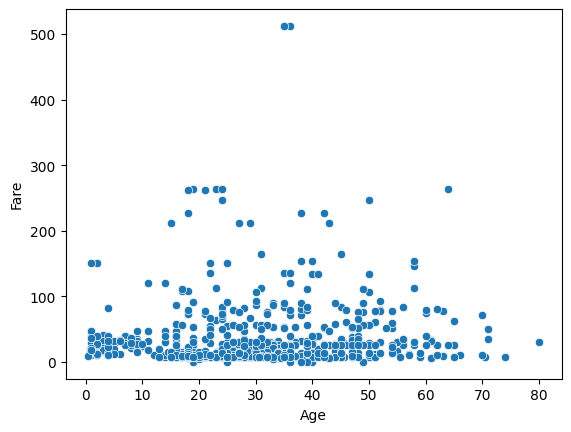

In [25]:
# X축값으로 Age를, Y축값으로 Fare를 설정
sns.scatterplot(x='Age', y='Fare', data=titanic_df)
plt.show()

+  ```hue``` 외에도 ```style```인자로 한 단계 더 세분화된 추가 정보를 제공할 수 있음

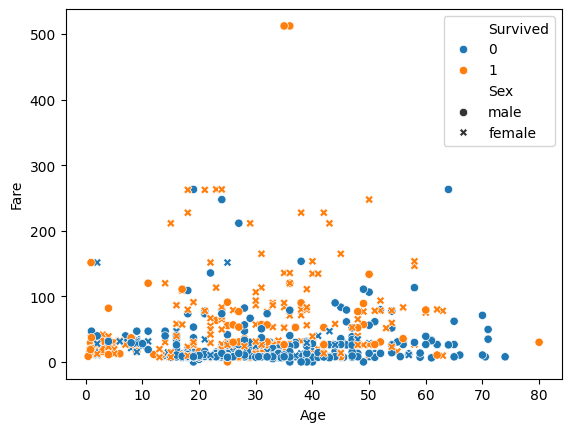

In [26]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Sex', data=titanic_df)
plt.show()

#### 상관 히트맵(Correlation Heatmap)

+ 상관 히트맵은 다수의 속성들 간의 상관계수를 히트맵 형태로 나타낼 수 있음
+  상관계수는 두 속성(변수/칼럼/피처)들 간의 선형적인 연관 관계를 수치화한 값
   * 두 속성의 값이 서로 상관없으면 0이
며, 같은 방향으로 완전히 동일하면 1, 반대 방향으로 완전히 동일하면 -1을 값으로 가짐
+  ```heatmap()```
   * 인자로 칼럼들 간의 상관계수를 가지는 DataFrame을 입력받아야 시각화가 가능
   * 판다스 DataFrame의 corr() 메서드를 호출하면 간단하게 상관계수를 가지는 DataFrame을 생성할 수 있음

In [27]:
corr_df = titanic_df.corr(numeric_only=True)
corr_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


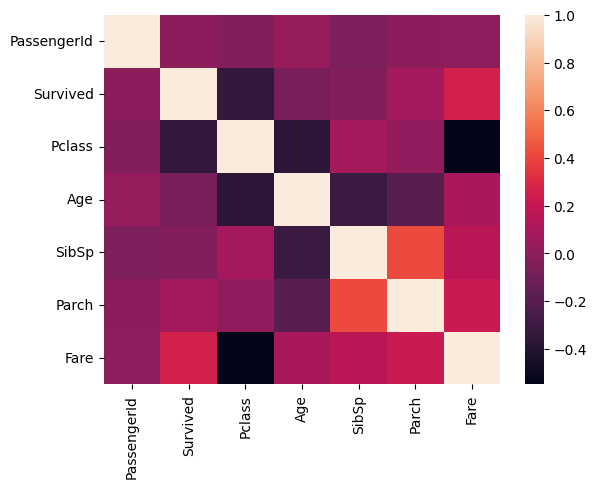

In [28]:
# 상관계수를 DataFrame으로 구하고 이를 heatmapO의 인자로 입력
corr = titanic_df.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

+ ```cmap```인자는 color map으로서 히트맵의 색상을 변경할 수 있음. 설정하지 않으면 기본으로 'rocket'으로 설정됨  
+ ```annot```인자는 True/False로 설정할 수 있으며 True인 경우 숫자로 된 *상관계숫값*을 표시해줌
+ ```fmt```인자로 숫자값의 포맷을 변환할 수 있음  
+ ```cbar```인자는 True/False로 설정할 수 있으며 True일 경우 숫자값에 따른 색깔 기준 막대로 표시

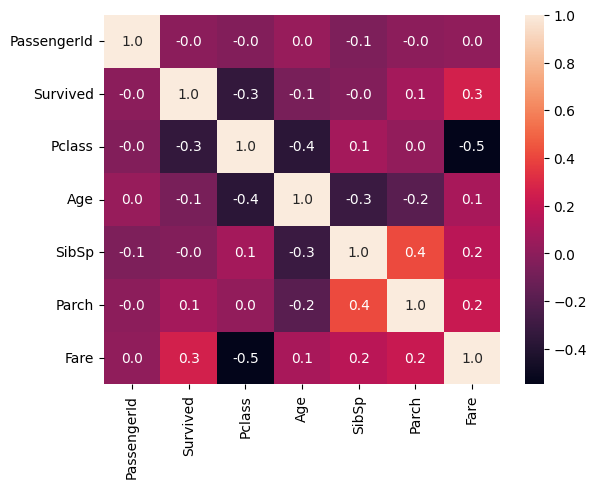

In [29]:
sns.heatmap(corr, annot=True, fmt='.1f', cbar=True)
plt.show()